# Exercícios
## 1) Modificar a profundidade da árvore e comparar resultados
**Objetivo:**

Entender como a profundidade (max_depth) influencia o underfitting e o overfitting.

Altere o parâmetro da árvore de decisão:

model = DecisionTreeClassifier(max_depth=3)

E teste diferentes valores:

max_depth = 1;
max_depth = 5;
max_depth = None (profundidade ilimitada)

Para cada profundidade:

1. Treine o modelo.
2. Plote a árvore de decisão.
3. Gere a fronteira de decisão.
4. Calcule as métricas: accuracy, precisão, recall, F1.

**Pergunta final:** Como a profundidade influencia o overfitting e o desempenho no teste?

## 2) Alterar o dataset e reavaliar o modelo
**Objetivo:**

Explorar como diferentes distribuições de dados afetam o comportamento da árvore.

Modifique o bloco:

X, y = make_classification(...)

Testando diferentes configurações:

1. Aumente o ruído dos rótulos
flip_y=0.15
2. Aumente o número de clusters por classe
n_clusters_per_class=2
3. Aumente o número de features informativas
n_features=4
n_informative=4

Para cada cenário:

1. Refaça o treino.
2. Plote (quando possível).
3. Gere a matriz de confusão.
4. Calcule accuracy, precisão, recall e F1.

**Pergunta final:** Em quais condições o modelo piora mais? Por quê?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_wine
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [ ]:
# Gerando um dataset sintético para o Exercício 1
X, y = make_classification(
    n_samples=300,             # Número de amostras
    n_features=15,             # Total de features
    n_informative=10,          # Features informativas
    n_redundant=5,             # Features redundantes
    n_classes=3,               # 3 classes
    n_clusters_per_class=1,    # 1 cluster por classe (valor inicial)
    flip_y=0.01,               # Ruído mínimo nos rótulos (valor inicial)
    random_state=42            # Para reprodutibilidade
)

# Criando nomes para as features e classes para facilitar a visualização
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
class_names = [f'class_{i}' for i in range(len(np.unique(y)))]

# Convertendo para DataFrame e Series para manter a consistência
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='label')

# Imprimindo informações sobre o novo dataset
print("Novo dataset gerado com make_classification:")
print(f"  Número de amostras: {X.shape[0]}")
print(f"  Número de features: {X.shape[1]}")
print(f"  Número de classes: {len(np.unique(y))}")
print(f"  Feature Names: {feature_names}")
print(f"  Class Names: {class_names}")

# Fazendo o split para treino e teste do modelo com estratificação (divisão equalitaria das classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Novo dataset gerado com make_classification:
  Número de amostras: 300
  Número de features: 15
  Número de classes: 3
  Feature Names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14']
  Class Names: ['class_0', 'class_1', 'class_2']


### Árvore de Decisão com max_depth=1


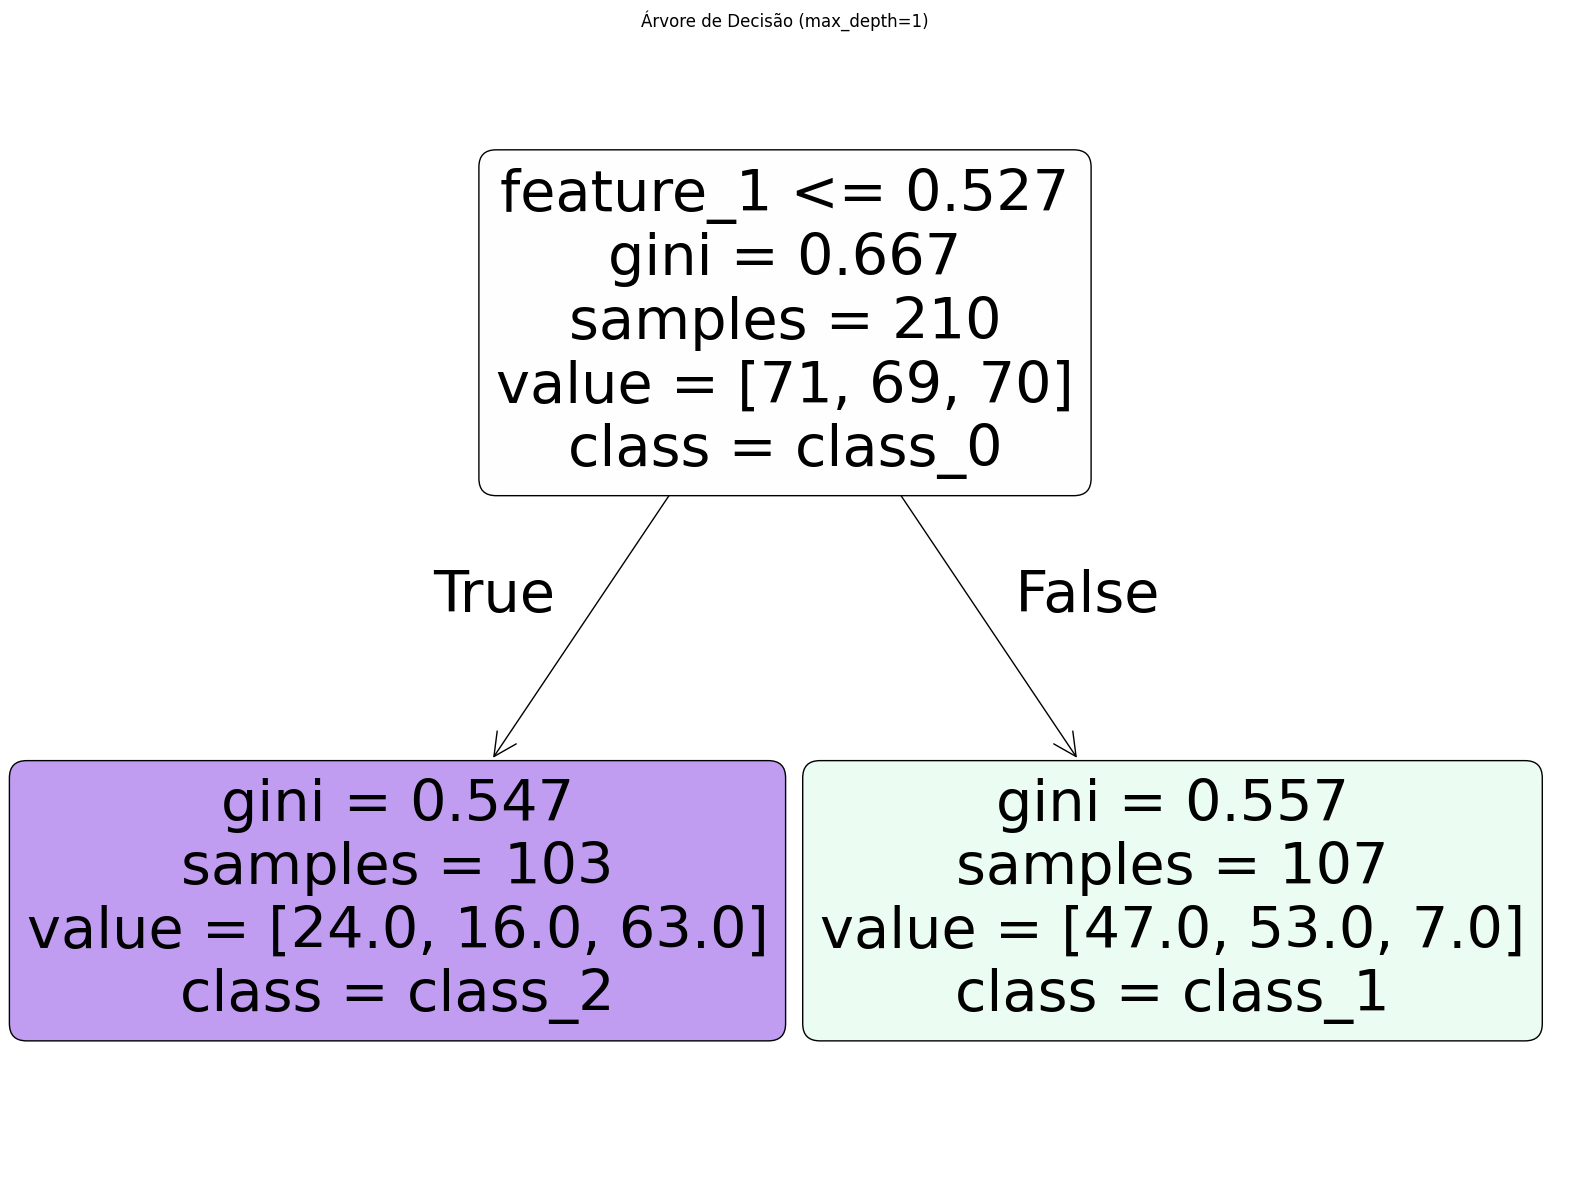

  Accuracy: 0.5111
  Precision: 0.3452
  Recall: 0.5111
  F1-Score: 0.4117


<Figure size 800x600 with 0 Axes>

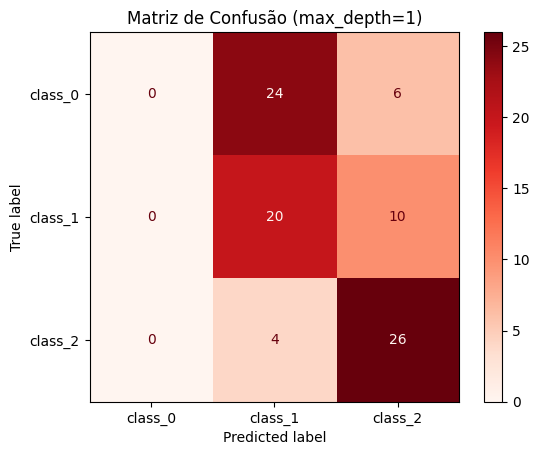





### Árvore de Decisão com max_depth=5


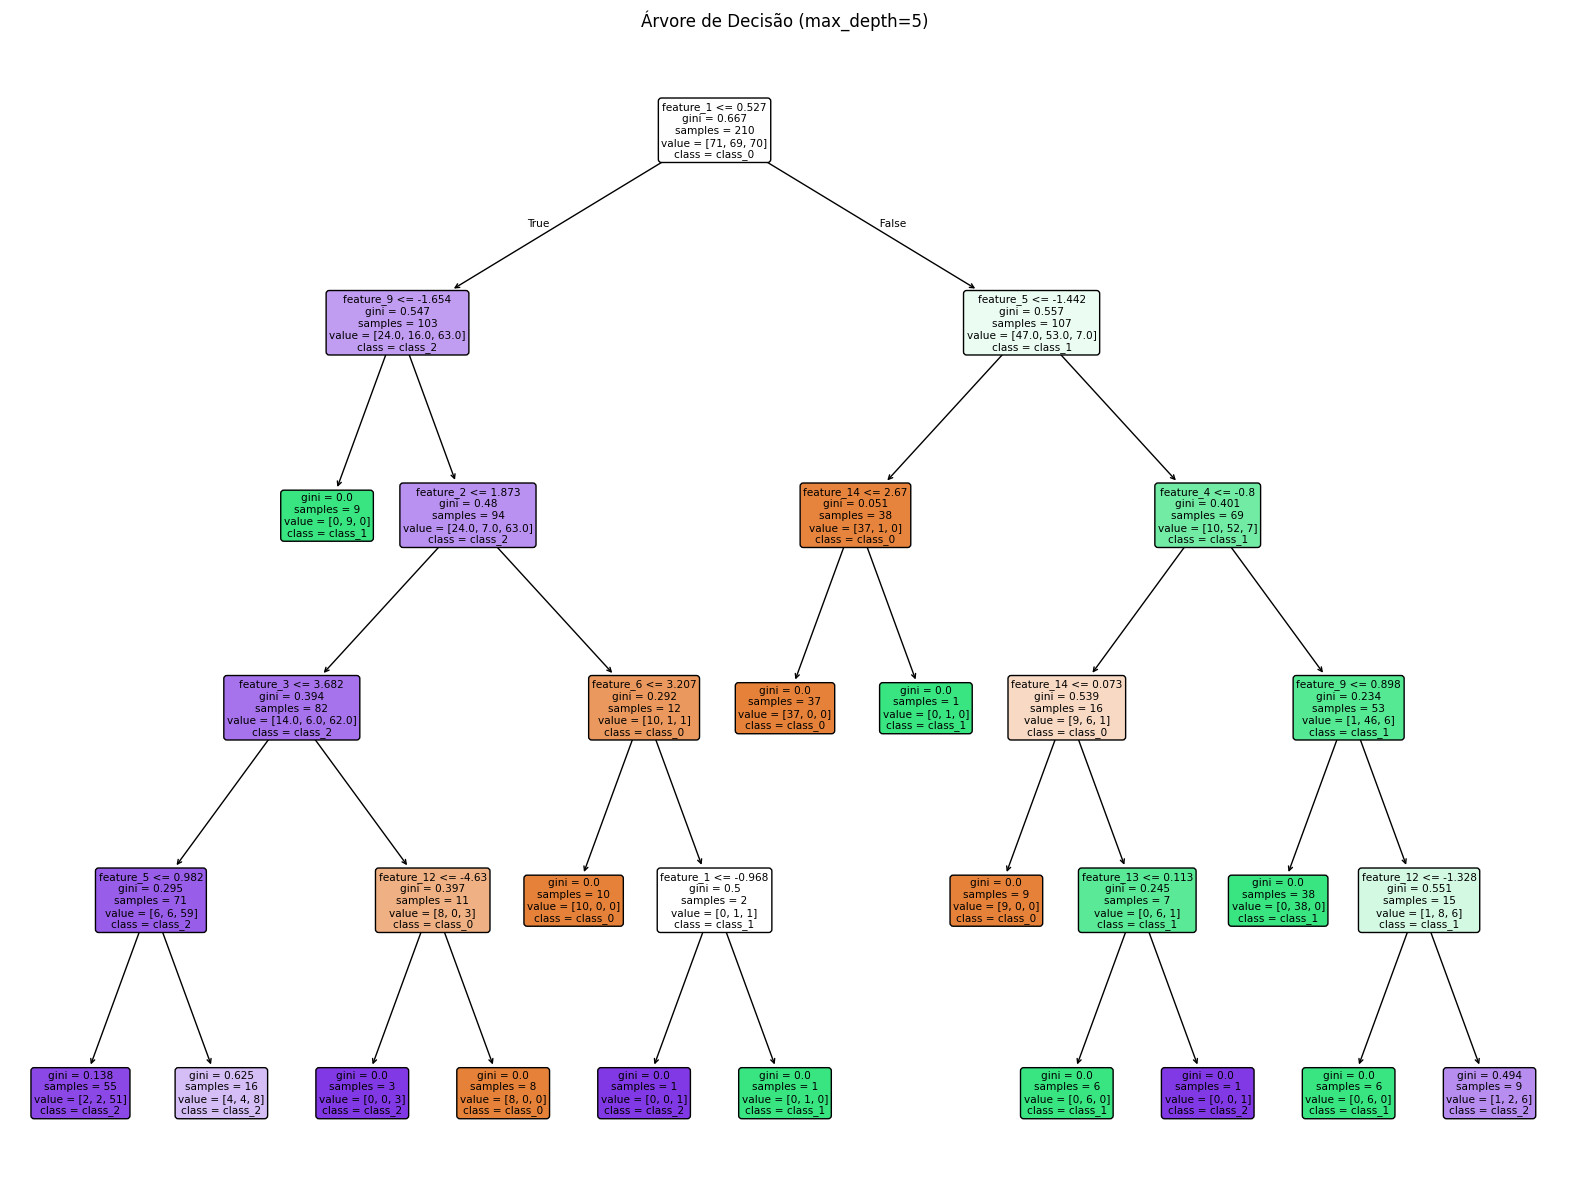

  Accuracy: 0.7667
  Precision: 0.7740
  Recall: 0.7667
  F1-Score: 0.7684


<Figure size 800x600 with 0 Axes>

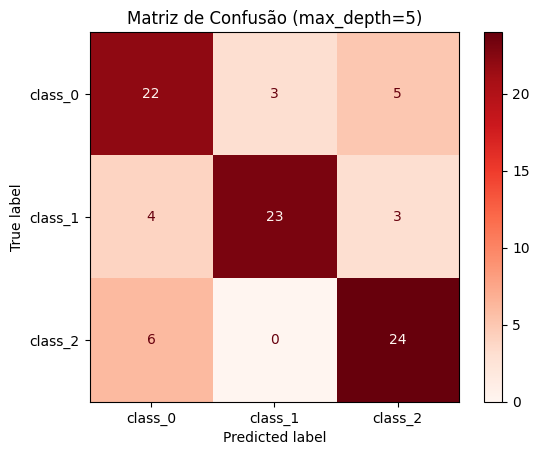





### Árvore de Decisão com max_depth=None


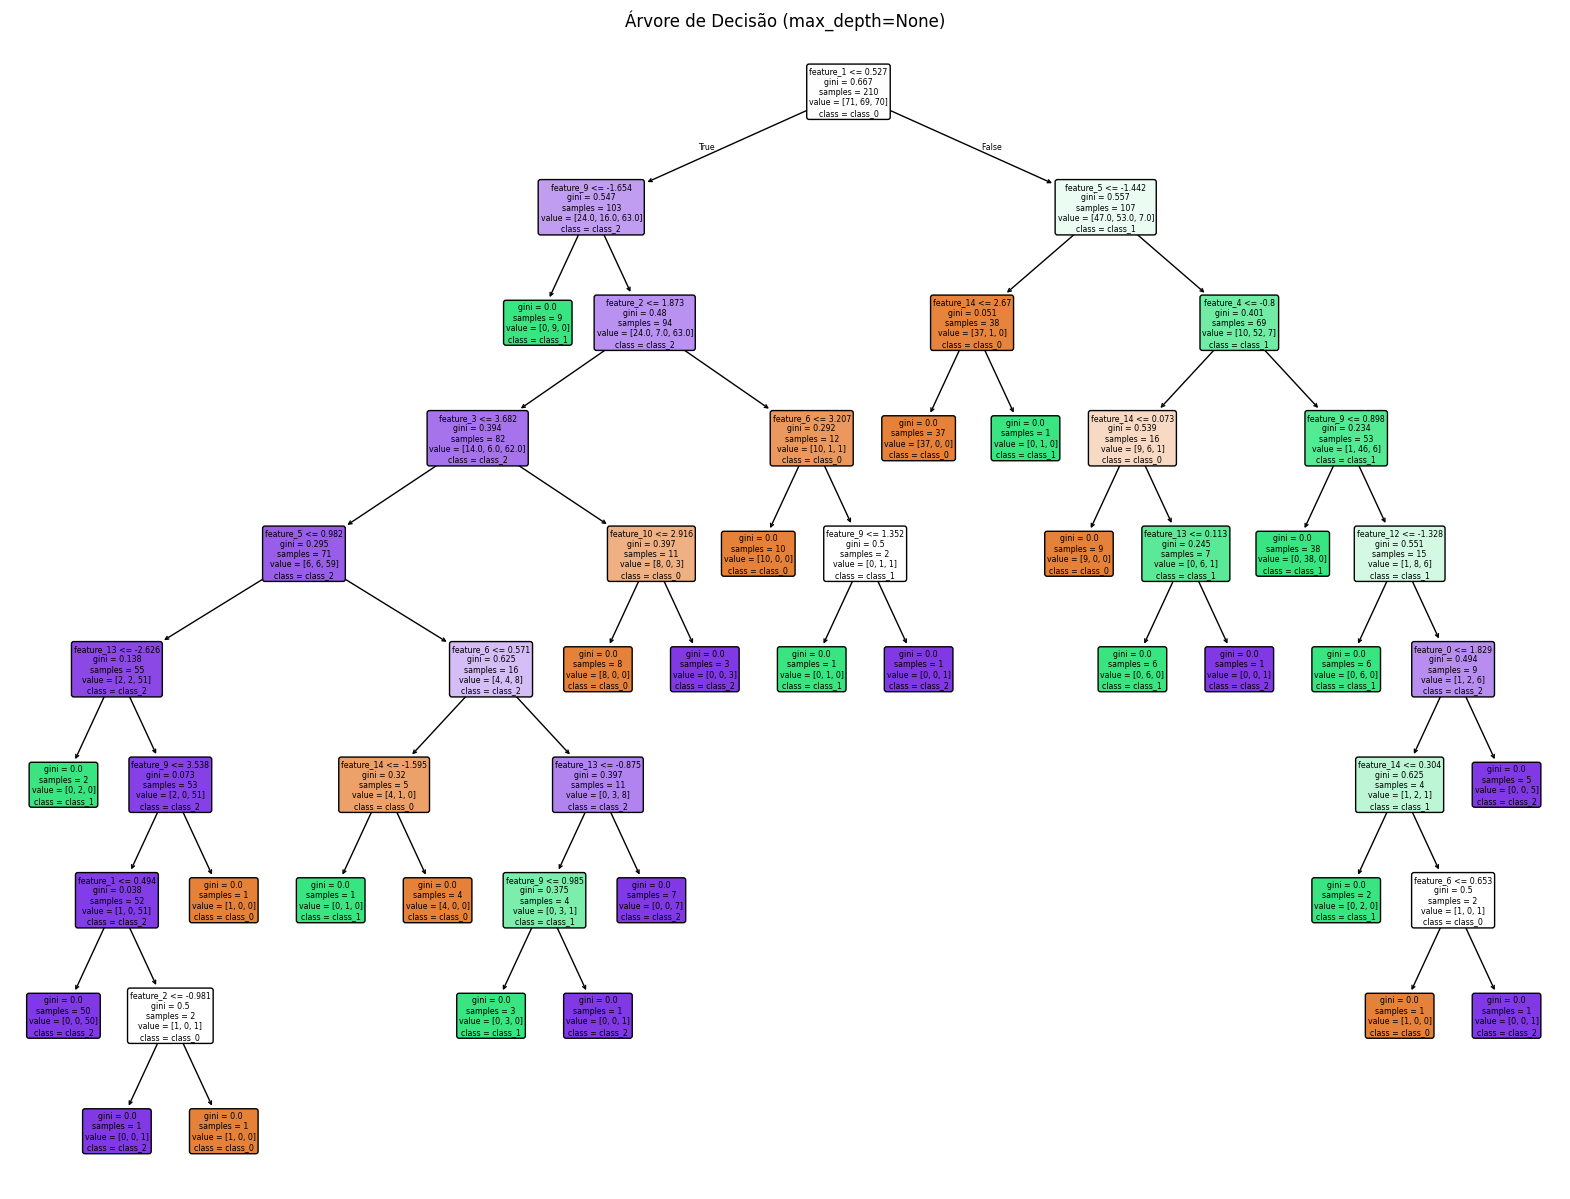

  Accuracy: 0.7556
  Precision: 0.7661
  Recall: 0.7556
  F1-Score: 0.7576


<Figure size 800x600 with 0 Axes>

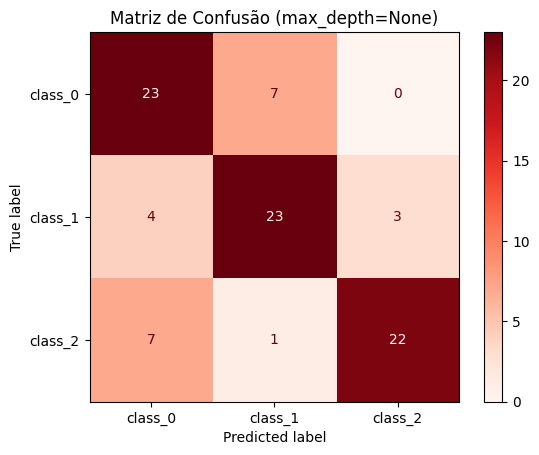

In [ ]:
# Para cada configuração de profundidade, treina e plota o modelo.
configs = [1, 5, None]

for config in configs:
    # Adiciona um cabeçalho para separar visualmente os plots e métricas
    print(f"### Árvore de Decisão com max_depth={config}")

    # Seta o modelo com a profundidade atual de forma reprodutivel
    model = DecisionTreeClassifier(max_depth=config, random_state=42)

    # Treina o modelo
    model.fit(X_train, y_train)

    # Faz a predição no conjunto de teste
    y_pred = model.predict(X_test)

    # Plota a árvore de decisão
    plt.figure(figsize=(20, 15))
    plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
    plt.title(f'Árvore de Decisão (max_depth={config})')
    plt.show()

    # Calcula e imprime as métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    # Gera e plota a matriz de confusão
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(f'Matriz de Confusão (max_depth={config})')
    plt.show()
    print("\n" + "="*100 + "\n\n\n") # Separador para o próximo config

## Analise dos resultados do Exercicio 1:

Como foi possivel perceber em nossos testes, caso o max_depth for muito pequeno, ele não se ajusta o suficiente com a complexidade dos dados e acaba gerando um underfitting, ou seja, não aprende o suficiente o padrão das amostras pois basicamente só faz uma pergunta de "sim ou não". Além de que em um exemplo multiclasse como esse, que tem 3 ou mais classes, o max_depth = 1 limita a decisao do modelo apenas a 2 classes, diminuindo o desempenho significativamente.

Quando esse max_depth vai aumentando, ele consegue melhorar a cada camada o gini, o qual enquanto vai reduzindo, vai "purificando" cada camada, deixando a cada pergunta mais separado as classes. O gini ideal é 0, que representa que naquela tomada de decisão, só vai haver uma classe possivel de acordo com as amostras.

Então no max_depth = 5, tivemos uma melhora visivel de desempenho, observavel na confusion matrix e nas métricas de desempenho, como a acurácia que saiu de **0.5111** e foi para **0.7667**.


No entanto é necessario cuidado para que o modelo não se ajuste demais as amostras, causando um overfitting.

Dito isso, o max_depth definido como None, vai criar o máximo de camadas que ele conseguir, pode acabar causando esse efeito de super ajuste, como percebido no teste realizado, que reduziu as metricas de desempenho, como a acurácia indo de **0.7667** para **0.7556** .

#Exercicio 2

### Árvore de Decisão com flip_y=0.15, n_clusters_per_class=1, n_features=15
Novo dataset gerado com make_classification:
  Número de amostras: 300
  Número de features: 15
  Número de classes: 3


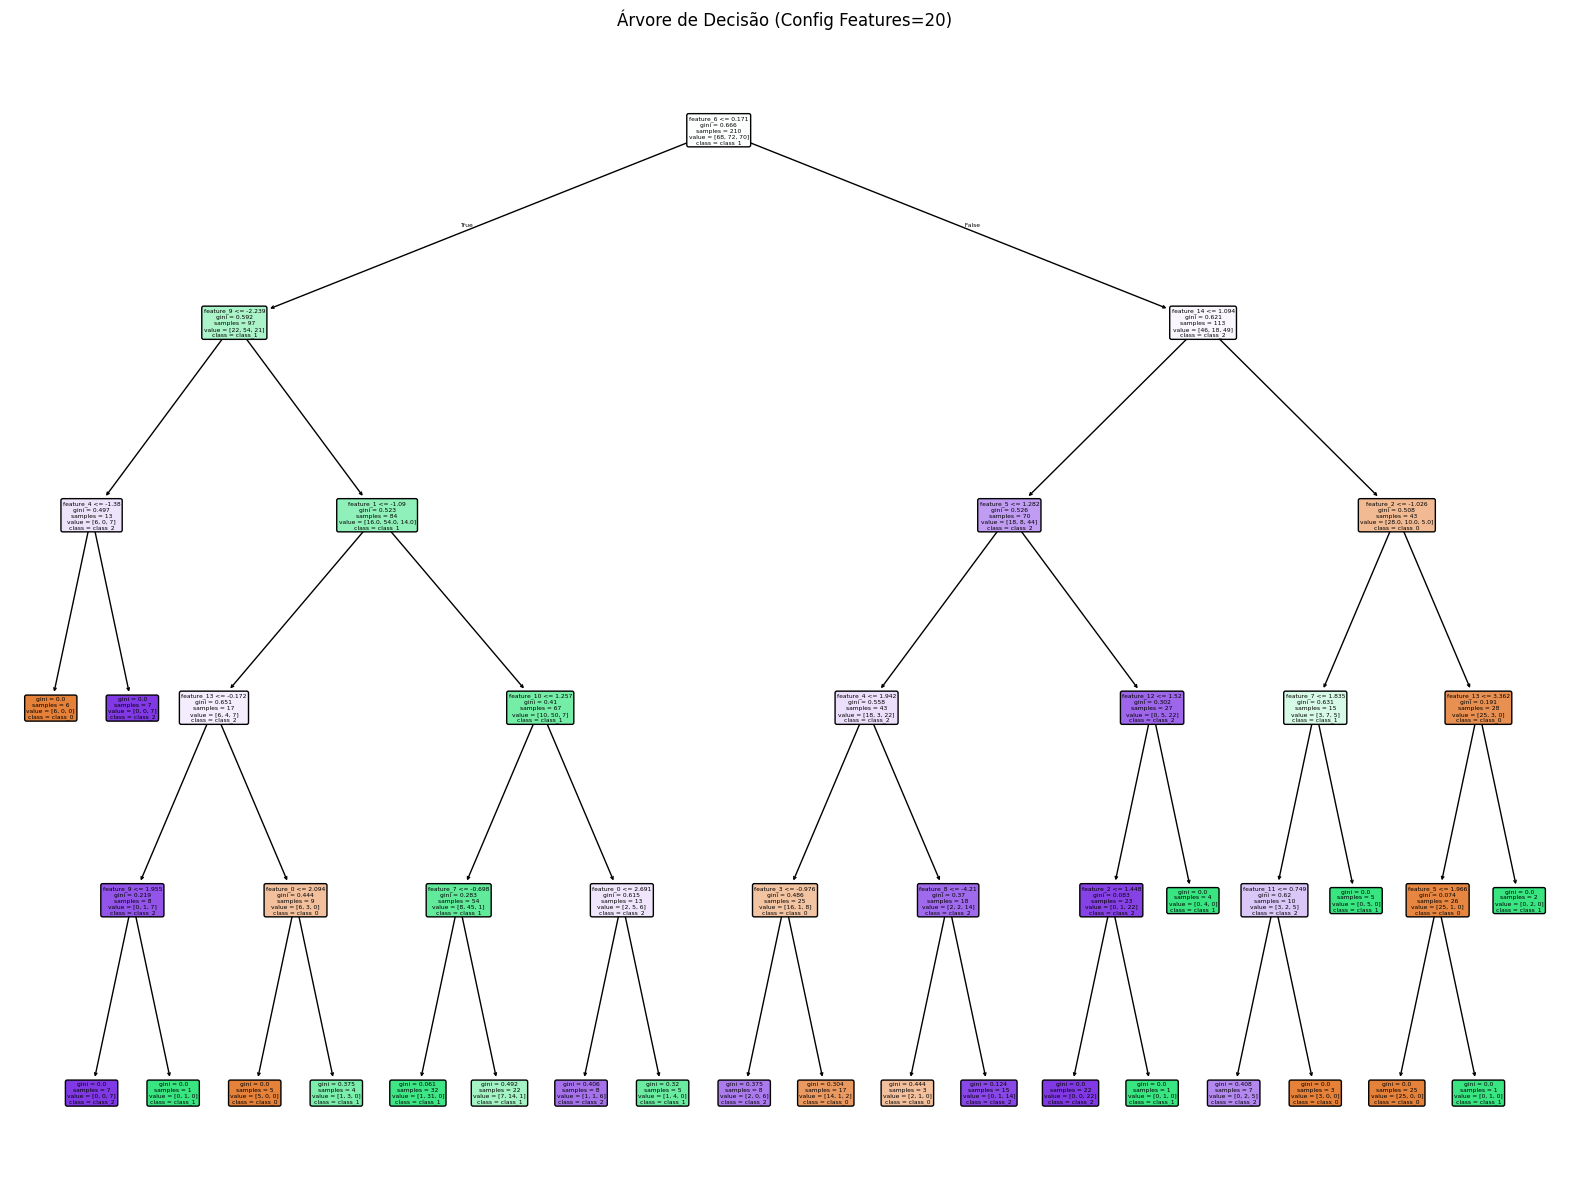

  Accuracy: 0.6444
  Precision: 0.6457
  Recall: 0.6444
  F1-Score: 0.6440


<Figure size 800x600 with 0 Axes>

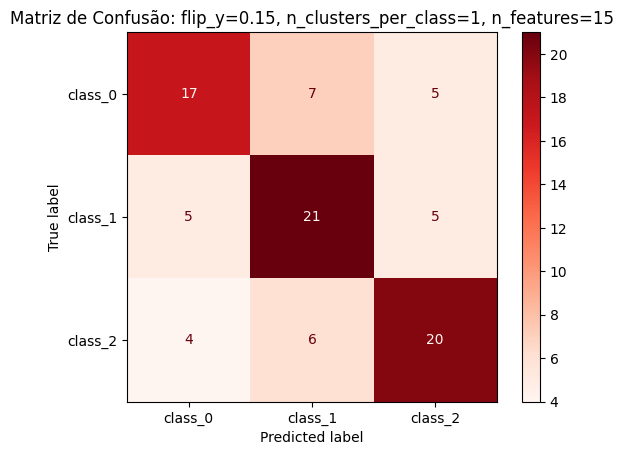





### Árvore de Decisão com flip_y=0.01, n_clusters_per_class=2, n_features=15
Novo dataset gerado com make_classification:
  Número de amostras: 300
  Número de features: 15
  Número de classes: 3


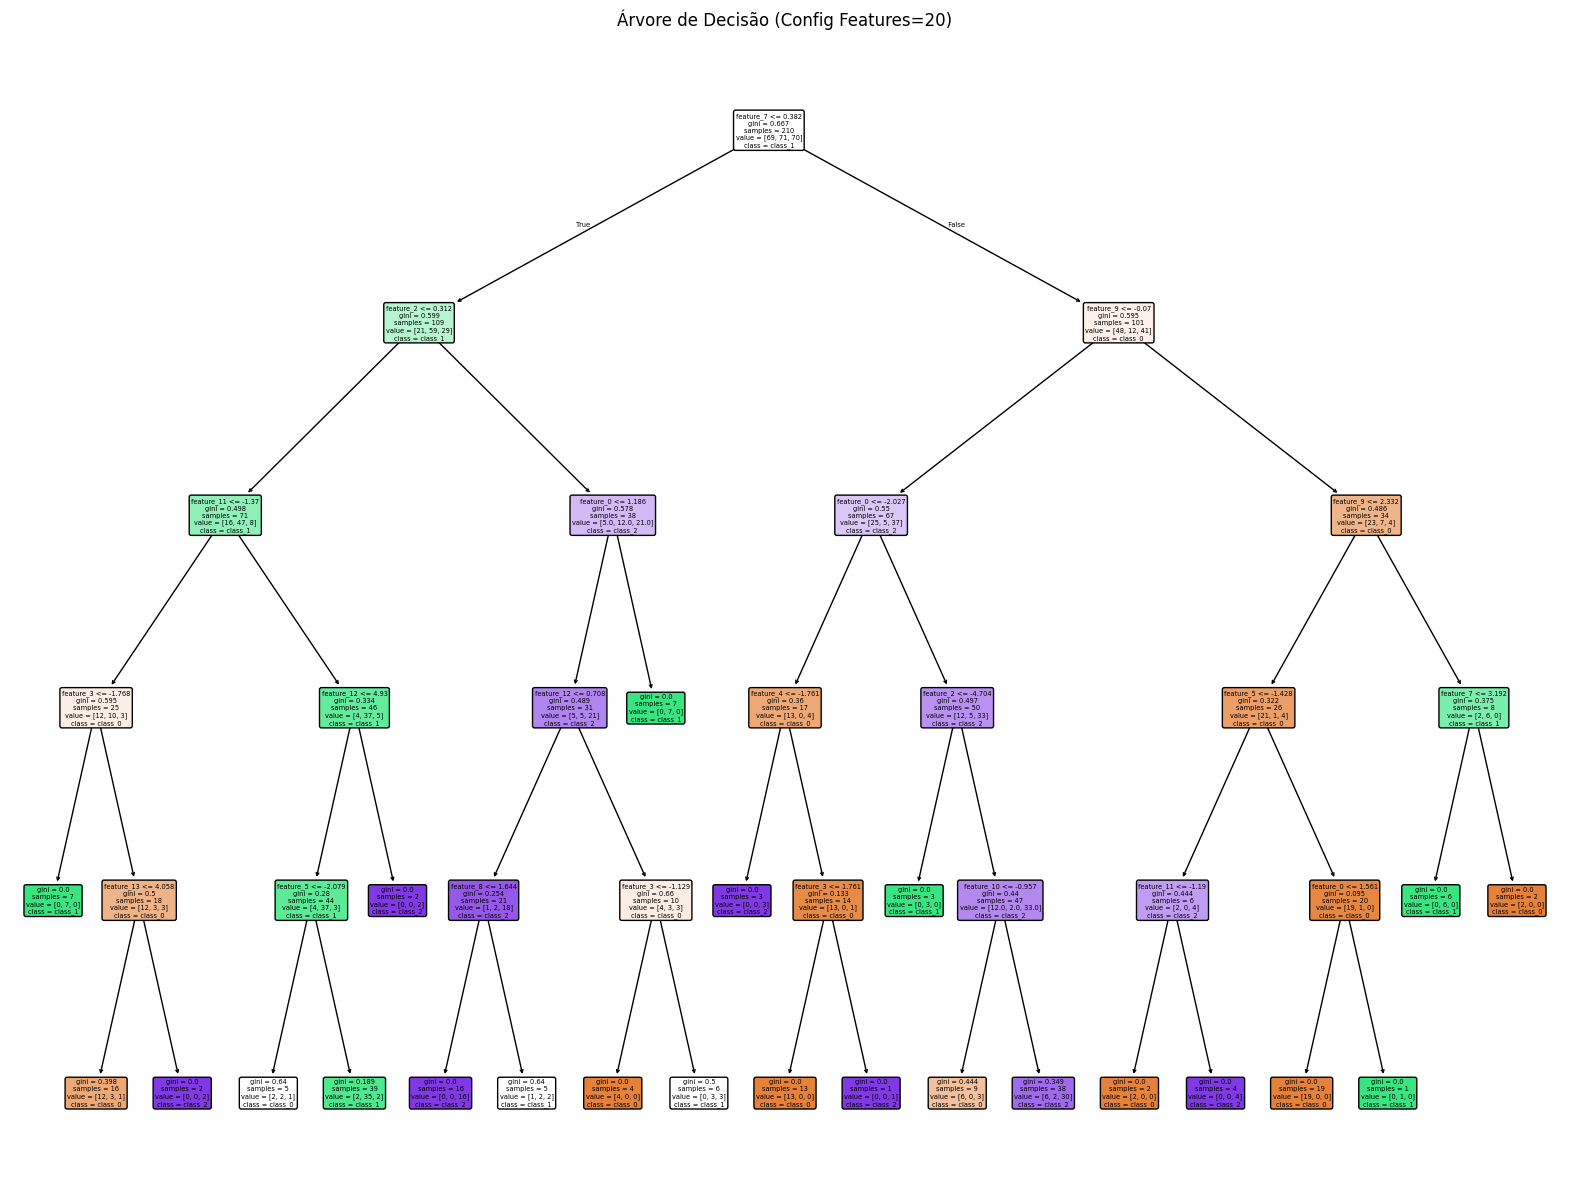

  Accuracy: 0.5556
  Precision: 0.5427
  Recall: 0.5556
  F1-Score: 0.5417


<Figure size 800x600 with 0 Axes>

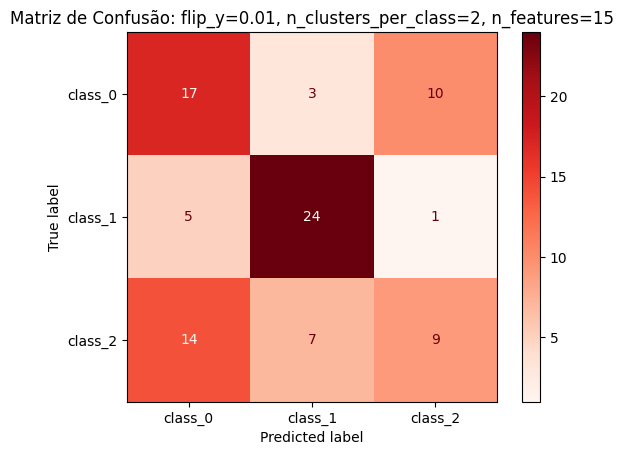





### Árvore de Decisão com flip_y=0.01, n_clusters_per_class=1, n_features=20
Novo dataset gerado com make_classification:
  Número de amostras: 300
  Número de features: 20
  Número de classes: 3


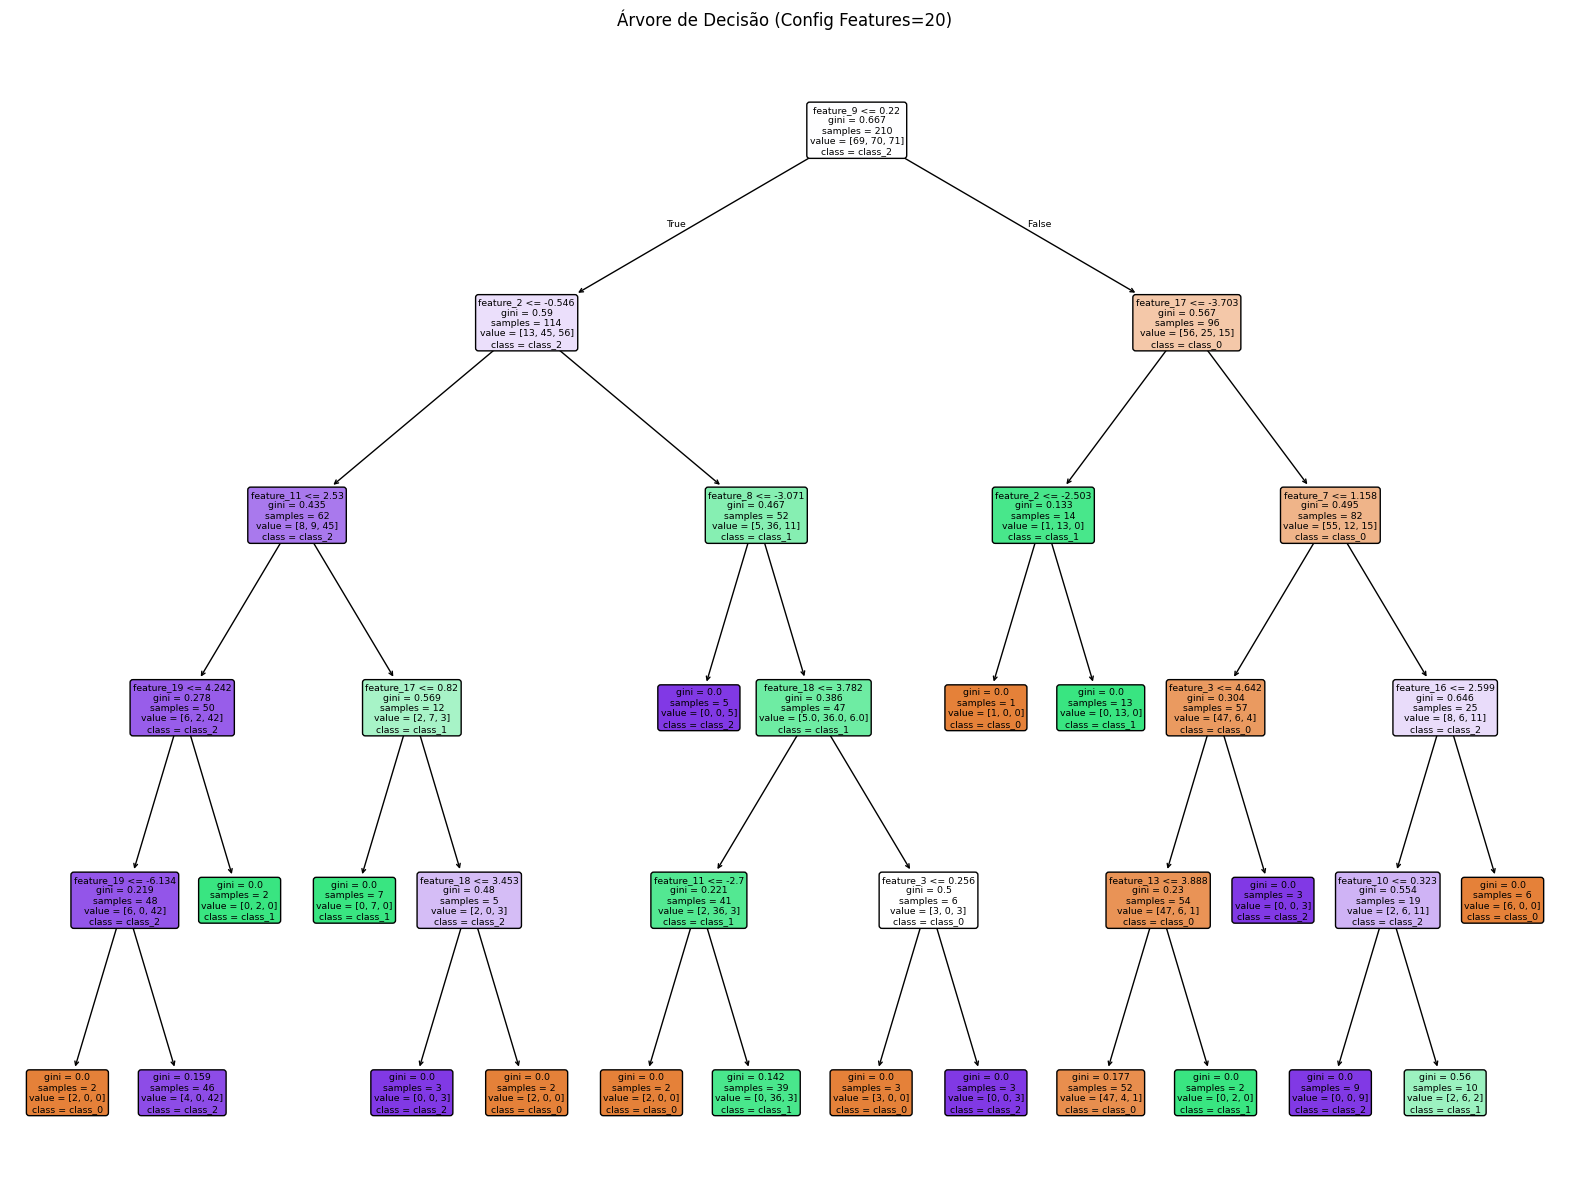

  Accuracy: 0.5667
  Precision: 0.5817
  Recall: 0.5667
  F1-Score: 0.5659


<Figure size 800x600 with 0 Axes>

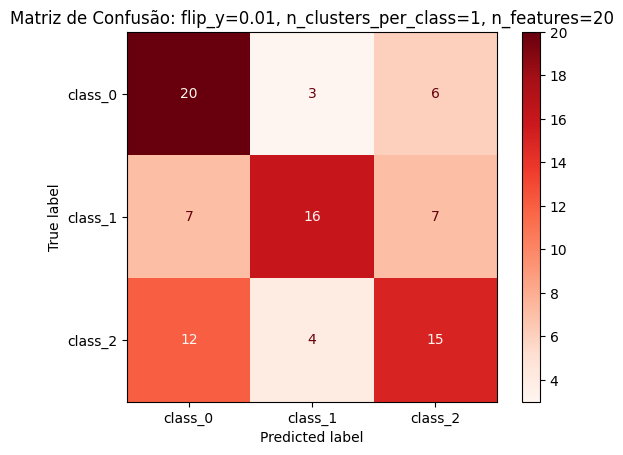

In [35]:
# Para cada configuração, treina e plota o modelo.
configs_flip_y = [0.15, 0.01, 0.01]
configs_n_clusters_per_class = [1, 2, 1]
configs_n_features = [15, 15, 20]

for config_f, config_cluster, config_features in zip(configs_flip_y, configs_n_clusters_per_class, configs_n_features):
    print(f"### Árvore de Decisão com flip_y={config_f}, n_clusters_per_class={config_cluster}, n_features={config_features}")

    # Gerando um dataset sintético para o Exercício 2

    X, y = make_classification(
        n_samples=300,
        n_features=config_features,       # Acompanha as config rotativa
        n_informative=config_features,
        n_redundant=0,                        # Adicionado para evitar erro de dimensões
        n_classes=3,
        n_clusters_per_class=config_cluster,
        flip_y=config_f,
        random_state=42
    )

    feature_names = [f'feature_{i}' for i in range(X.shape[1])]
    class_names = [f'class_{i}' for i in range(len(np.unique(y)))]

    X = pd.DataFrame(X, columns=feature_names)
    y = pd.Series(y, name='label')

    print("Novo dataset gerado com make_classification:")
    print(f"  Número de amostras: {X.shape[0]}")
    print(f"  Número de features: {X.shape[1]}")
    print(f"  Número de classes: {len(np.unique(y))}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Deixando padrao com max_depth em 5 pois foi o melhor resultado no ex 1
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Plot da árvore
    plt.figure(figsize=(20, 15))
    plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
    plt.title(f'Árvore de Decisão (Config Features={config})')
    plt.show()

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    # Matriz de confusão
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(f"Matriz de Confusão: flip_y={config_f}, n_clusters_per_class={config_cluster}, n_features={config_features}")
    plt.show()
    print("\n" + "="*100 + "\n\n\n")

A análise dos resultados do Exercício 2 demonstra como diferentes alterações na estrutura dos dados impactam uma Árvore de Decisão com profundidade limitada (max_depth=5). Em comparação com a linha de base inicial, que apresentava uma acurácia de 0.7667, todos os cenários testados causaram degradação no desempenho, mas por motivos distintos.

No cenário de aumento de ruído (flip_y=0.15), a acurácia caiu para 0.6444. Isso ocorre porque a introdução de rótulos incorretos confunde o algoritmo durante o processo de partição dos nós. Como a árvore busca maximizar a pureza de cada divisão, ela acaba tentando aprender os erros presentes nos dados rotulados incorretamente. Esse processo gera fronteiras de decisão que se ajustam ao ruído e não ao padrão real, prejudicando a capacidade do modelo de classificar novos dados.

Já no cenário com dois clusters por classe, o impacto foi menor, com uma acurácia de 0.7222. O desafio aqui é a complexidade espacial: em vez de uma massa única de dados, cada classe está dividida em sub-regiões diferentes. Embora a árvore tenha conseguido identificar parte dessa fragmentação, a profundidade limitada a 5 níveis impede que o modelo crie divisões suficientes para isolar perfeitamente todos os grupos, resultando em uma pequena perda de precisão.

O pior desempenho foi observado no cenário de alta dimensionalidade, onde todas as 20 variáveis eram informativas, resultando em uma acurácia de 0.5667. Este caso ilustra a "maldição da dimensionalidade": com muitas variáveis e poucas amostras (300), os dados tornam-se esparsos no espaço multidimensional. Uma árvore com profundidade 5 é incapaz de explorar as interações complexas entre 20 atributos diferentes ao mesmo tempo. O modelo sofre de um subajuste (underfitting) severo, pois sua estrutura é simples demais para a complexidade do problema proposto.

Em conclusão, o modelo piora mais significativamente quando o número de features informativas aumenta sem um aumento correspondente na profundidade da árvore ou no volume de dados. Embora o ruído e a fragmentação de clusters dificultem o aprendizado, a alta dimensionalidade provou ser o obstáculo mais crítico para a arquitetura limitada do modelo testado.